# temperature anomaly calculation vs. 30-year baseline

In [116]:
import pandas as pd

df = pd.read_csv("../../../scripts/python/Yashaswi/temp_clean.csv", 
                    dtype={"Climate ID": "string"},
                    low_memory=False
)
stations = pd.read_csv("../Yashaswi/stations_with_municipality_and_province.csv")

df["Date"] = pd.to_datetime(df["Date"])
df["Year"]  = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"]   = df["Date"].dt.day

In [117]:
df.columns

Index(['temp_Index', 'Climate ID', 'Date', 'Max Temp (°C)', 'Min Temp (°C)',
       'Mean Temp (°C)', 'Heat Deg Days (°C)', 'Cool Deg Days (°C)', 'Year',
       'Month', 'Day'],
      dtype='str')

In [118]:
df.head()

,temp_Index,Climate ID,Date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Year,Month,Day
0,1000,8204020,2021-09-11,18.7,8.7,13.7,4.3,0.0,2021,9,11
1,1001,8204020,2021-09-12,22.4,9.8,16.1,1.9,0.0,2021,9,12
2,1002,8204020,2021-09-13,20.8,11.0,15.9,2.1,0.0,2021,9,13
3,1003,8204020,2021-09-14,17.2,6.9,12.1,5.9,0.0,2021,9,14
4,1004,8204020,2021-09-15,20.2,5.7,13.0,5.0,0.0,2021,9,15


In [119]:
stations.columns

Index(['Station ID', 'Latitude', 'Longitude', 'CSDUID', 'CSDNAME', 'Province'], dtype='str')

In [121]:

df = df.rename(columns={"Climate ID": "station_id"})
stations = stations.rename(columns={"Station ID": "station_id"})


In [122]:
df = df.merge(
    stations,
    on="station_id",
    how="left"
)

In [123]:
df["CSDNAME"].isna().mean()

np.float64(0.0)

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 818993 entries, 0 to 818992
Data columns (total 16 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   temp_Index          818993 non-null  int64         
 1   station_id          818993 non-null  object        
 2   Date                818993 non-null  datetime64[us]
 3   Max Temp (°C)       814288 non-null  float64       
 4   Min Temp (°C)       816921 non-null  float64       
 5   Mean Temp (°C)      818993 non-null  float64       
 6   Heat Deg Days (°C)  812218 non-null  float64       
 7   Cool Deg Days (°C)  812218 non-null  float64       
 8   Year                818993 non-null  int32         
 9   Month               818993 non-null  int32         
 10  Day                 818993 non-null  int32         
 11  Latitude            818993 non-null  float64       
 12  Longitude           818993 non-null  float64       
 13  CSDUID              818993 non-null  int

In [22]:
df.loc[
    (df["station_id"] == "8100300") &
    (df["Month"] == 1) &
    (df["Day"] == 1),
    ["Year", "Mean Temp (°C)"]
]

,Year,Mean Temp (°C)
10985,1995,-11.0
11350,1996,-21.8
11716,1997,-17.0
12081,1998,-16.3
12446,1999,-26.5
12811,2000,-11.3
13177,2001,0.0
13753,2004,-7.5
14119,2005,3.0
14361,2008,-9.3


## Temperature Anomaly  (30‑Year Baseline)

In [125]:
BASELINE_START = 1995
BASELINE_END   = 2025

df_baseline_src = df[
    (df["Year"] >= BASELINE_START) &
    (df["Year"] <= BASELINE_END)
]

## Compute daily climatology baseline

In [126]:
baseline = (
    df_baseline_src
    .groupby(["station_id", "Month", "Day"], as_index=False)
    ["Mean Temp (°C)"]
    .mean()
    .rename(columns={
        "Mean Temp (°C)": "Baseline Mean Temp (°C)"
    })
)
baseline.head(3)

,station_id,Month,Day,Baseline Mean Temp (°C)
0,8100300,1,1,-8.660000
1,8100300,1,2,-9.565385
2,8100300,1,3,-10.623077


## Merge baseline to full dataset

In [127]:

# Drop existing baseline/anomaly columns if they exist
df = df.drop(
    columns=["Baseline Mean Temp (°C)", "Temp Anomaly (°C)"],
    errors="ignore"
)

df = df.merge(
    baseline,
    on=["station_id", "Month", "Day"],
    how="left"
)
df.loc[
    (df["station_id"] == "8100300") &
    (df["Month"] == 1) &
    (df["Day"] == 1),
    ["Year", "Mean Temp (°C)","Baseline Mean Temp (°C)"]
]

,Year,Mean Temp (°C),Baseline Mean Temp (°C)
10755,1995,-11.0,-8.66
11120,1996,-21.8,-8.66
11486,1997,-17.0,-8.66
11851,1998,-16.3,-8.66
12216,1999,-26.5,-8.66
12581,2000,-11.3,-8.66
12947,2001,0.0,-8.66
13523,2004,-7.5,-8.66
13889,2005,3.0,-8.66
14131,2008,-9.3,-8.66


## Calculate temperature anomaly

In [128]:
df["Temp Anomaly (°C)"] = (
    df["Mean Temp (°C)"] -
    df["Baseline Mean Temp (°C)"]
)

## Quality‑assurance checks 

In [129]:
print("Missing baseline (%):",
      df["Baseline Mean Temp (°C)"].isna().mean() * 100)

Missing baseline (%): 0.0


In [130]:
df["Temp Anomaly (°C)"].describe()

count    8.189930e+05
mean    -1.388130e-18
std      3.744718e+00
min     -2.942500e+01
25%     -2.327586e+00
50%     -7.200000e-02
75%      2.281818e+00
max      2.127500e+01
Name: Temp Anomaly (°C), dtype: float64

In [131]:
df.columns

Index(['temp_Index', 'station_id', 'Date', 'Max Temp (°C)', 'Min Temp (°C)',
       'Mean Temp (°C)', 'Heat Deg Days (°C)', 'Cool Deg Days (°C)', 'Year',
       'Month', 'Day', 'Latitude', 'Longitude', 'CSDUID', 'CSDNAME',
       'Province', 'Baseline Mean Temp (°C)', 'Temp Anomaly (°C)'],
      dtype='str')

In [132]:
baseline_df = df[[
    "station_id",
    "Month",
    "Day",
    "Baseline Mean Temp (°C)"
]]
baseline_df.head()

,station_id,Month,Day,Baseline Mean Temp (°C)
0,8204020,9,11,16.54
1,8204020,9,12,15.80
2,8204020,9,13,17.14
3,8204020,9,14,15.64
4,8204020,9,15,14.30


## ✅ Step 2: Verify uniqueness (VERY important)
- ✅ Expected result: empty Series
- ❌ If not empty → conflicting baselines exist and must be resolved

In [133]:
dup_check = (
    baseline_df
    .groupby(["station_id", "Month", "Day"])["Baseline Mean Temp (°C)"]
    .nunique()
)

dup_check[dup_check > 1]

Series([], Name: Baseline Mean Temp (°C), dtype: int64)

In [38]:
baseline_df.groupby("station_id").size().describe()

count      136.000000
mean      6126.389706
std       3127.370298
min        244.000000
25%       3318.250000
50%       5643.500000
75%       8425.250000
max      11436.000000
dtype: float64

In [134]:
baseline_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 818993 entries, 0 to 818992
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   station_id               818993 non-null  object 
 1   Month                    818993 non-null  int32  
 2   Day                      818993 non-null  int32  
 3   Baseline Mean Temp (°C)  818993 non-null  float64
dtypes: float64(1), int32(2), object(1)
memory usage: 18.7+ MB


In [135]:
baseline_variation = (
    baseline_df
    .groupby(["station_id", "Month", "Day"])["Baseline Mean Temp (°C)"]
    .nunique()
)
baseline_variation[baseline_variation > 1]

Series([], Name: Baseline Mean Temp (°C), dtype: int64)

In [136]:
baseline_days_per_station = (
    baseline_df
    .drop_duplicates(["station_id", "Month", "Day"])
    .groupby("station_id")
    .size()
)

baseline_days_per_station.describe()

count    136.000000
mean     364.485294
std       15.743304
min      183.000000
25%      366.000000
50%      366.000000
75%      366.000000
max      366.000000
dtype: float64

In [137]:
baseline_unique = (
    baseline_df
    .groupby(
        ["station_id", "Month", "Day"],
        as_index=False
    )["Baseline Mean Temp (°C)"]
    .first()
)

In [138]:
baseline_unique.info()

<class 'pandas.DataFrame'>
RangeIndex: 49570 entries, 0 to 49569
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   station_id               49570 non-null  str    
 1   Month                    49570 non-null  int32  
 2   Day                      49570 non-null  int32  
 3   Baseline Mean Temp (°C)  49570 non-null  float64
dtypes: float64(1), int32(2), str(1)
memory usage: 1.1 MB


In [139]:
baseline_unique.to_csv(
    "Baseline_per_Station.csv",
    index=False
)

In [40]:
baseline_days = (
    baseline_df
    .groupby("station_id")[["Month", "Day"]]
    .apply(lambda x: x.drop_duplicates().shape[0])
)
baseline_days

station_id
8100300    366
8100467    366
8100468    183
8100506    366
8100885    366
          ... 
8502801    366
8502810    366
8503249    366
8504176    361
8504177    366
Length: 136, dtype: int64

In [41]:
baseline_days.describe()

count    136.000000
mean     364.544118
std       15.703676
min      183.000000
25%      366.000000
50%      366.000000
75%      366.000000
max      366.000000
dtype: float64

In [42]:
(baseline_days == 365).all()


np.False_

In [45]:
stations_lt_360 = baseline_days[baseline_days < 360]
stations_lt_360

station_id
8100468    183
8501136    358
dtype: int64

In [60]:
bi_anomaly_table = df[
    [
        "station_id",
        "Date",
        "Baseline Mean Temp (°C)",
        "Temp Anomaly (°C)"
    ]
].copy()
bi_anomaly_table["Date"] = pd.to_datetime(bi_anomaly_table["Date"])
bi_anomaly_table["station_id"] = bi_anomaly_table["station_id"].astype(str)

In [62]:
bi_anomaly_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 833189 entries, 0 to 833188
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   station_id               833189 non-null  str           
 1   Date                     833189 non-null  datetime64[us]
 2   Baseline Mean Temp (°C)  833181 non-null  float64       
 3   Temp Anomaly (°C)        833181 non-null  float64       
dtypes: datetime64[us](1), float64(2), str(1)
memory usage: 25.4 MB


In [106]:
# Round only float columns to 4 decimal places
float_cols = bi_anomaly_table.select_dtypes(include="float").columns

bi_anomaly_table[float_cols] = bi_anomaly_table[float_cols].round(4)
float_cols = bi_anomaly_table.select_dtypes(include="float").columns
bi_anomaly_table[float_cols] = bi_anomaly_table[float_cols].astype("float32")

In [107]:
bi_anomaly_table.info()

<class 'pandas.DataFrame'>
RangeIndex: 833189 entries, 0 to 833188
Data columns (total 4 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   station_id               833189 non-null  str           
 1   Date                     833189 non-null  datetime64[us]
 2   Baseline Mean Temp (°C)  833181 non-null  float32       
 3   Temp Anomaly (°C)        833181 non-null  float32       
dtypes: datetime64[us](1), float32(2), str(1)
memory usage: 19.1 MB


In [109]:
bi_anomaly_table.groupby(
    ["station_id", bi_anomaly_table["Date"].dt.month, bi_anomaly_table["Date"].dt.day]
)["Baseline Mean Temp (°C)"].nunique().describe()

count    49578.000000
mean         0.999839
std          0.012702
min          0.000000
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: Baseline Mean Temp (°C), dtype: float64

In [140]:
bi_anomaly_table = bi_anomaly_table[
    bi_anomaly_table["Date"] <= "2025-12-31"
].copy()

In [141]:
bi_anomaly_table.to_csv(
    "temperature_anomalies.csv",
    index=False
)

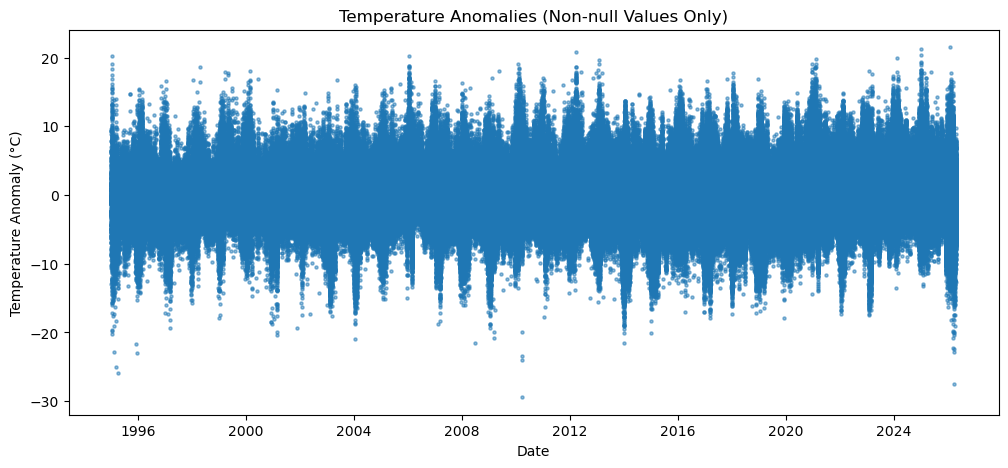

In [63]:
import matplotlib.pyplot as plt

# 1. Keep only non-null anomaly values
anom_df = bi_anomaly_table.dropna(subset=["Temp Anomaly (°C)"])

# 2. Scatter plot (dots only)
plt.figure(figsize=(12, 5))
plt.scatter(
    anom_df["Date"],
    anom_df["Temp Anomaly (°C)"],
    s=5,              # small dots
    alpha=0.5         # transparency for dense data
)

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Temperature Anomalies (Non-null Values Only)")
plt.show()

## Filter only severe, non‑null anomalies

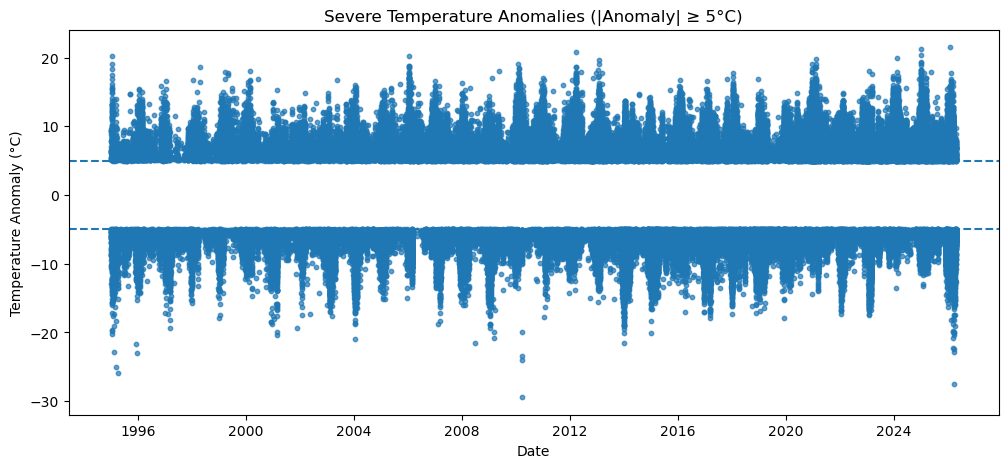

In [64]:
import matplotlib.pyplot as plt

# Keep only non-null anomalies
anom_df = bi_anomaly_table.dropna(subset=["Temp Anomaly (°C)"])

# Define severity threshold
SEVERE_THRESHOLD = 5.0

# Filter severe anomalies (hot OR cold)
severe_anom_df = anom_df[
    (anom_df["Temp Anomaly (°C)"] >= SEVERE_THRESHOLD) |
    (anom_df["Temp Anomaly (°C)"] <= -SEVERE_THRESHOLD)
]

plt.figure(figsize=(12, 5))

plt.scatter(
    severe_anom_df["Date"],
    severe_anom_df["Temp Anomaly (°C)"],
    s=10,
    alpha=0.7
)

plt.axhline(SEVERE_THRESHOLD, linestyle="--")
plt.axhline(-SEVERE_THRESHOLD, linestyle="--")

plt.xlabel("Date")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Severe Temperature Anomalies (|Anomaly| ≥ 5°C)")
plt.show()

## ✅ 1. Check if each station has only ONE row per date (most important)
✅ Interpretation

- False → ✅ each station has only one row per date
- True → ❌ duplicates exist (problem)

In [31]:
bi_anomaly_table.duplicated(subset=["station_id", "Date"]).any()

np.False_

In [32]:
bi_anomaly_table.duplicated(
    subset=["station_id", "Date"]
).sum()

np.int64(0)

In [33]:
baseline_check = (
    bi_anomaly_table
    .groupby(["station_id", "Date"])["Baseline Mean Temp (°C)"]
    .nunique()
)

baseline_check[baseline_check > 1]

Series([], Name: Baseline Mean Temp (°C), dtype: int64)

## Monthly anomalies

In [112]:
monthly_anomaly = (
    df.groupby(["station_id", "Year", "Month"])["Temp Anomaly (°C)"]
      .mean()
      .reset_index()
)

## Seasonal anomalies

In [75]:
season_map = {
    12:"Winter", 1:"Winter", 2:"Winter",
     3:"Spring", 4:"Spring", 5:"Spring",
     6:"Summer", 7:"Summer", 8:"Summer",
     9:"Fall",  10:"Fall",  11:"Fall"
}

df["Season"] = df["Month"].map(season_map)

seasonal_anomaly = (
    df.groupby(["station_id", "Year", "Season"])["Temp Anomaly (°C)"]
      .mean()
      .reset_index()
)
seasonal_anomaly.head()

,station_id,Year,Season,Temp Anomaly (°C)
0,8100300,1995,Fall,-0.246746
1,8100300,1995,Spring,-1.157469
2,8100300,1995,Summer,0.618825
3,8100300,1995,Winter,-1.847593
4,8100300,1996,Fall,-0.948944


In [ ]:
import matplotlib.pyplot as plt

# Average across all stations per Year & Season
seasonal_avg = (
    seasonal_anomaly
    .groupby(["Year", "Season"])["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for season in ["Winter", "Spring", "Summer", "Fall"]:
    data = seasonal_avg[seasonal_avg["Season"] == season]
    plt.plot(
        data["Year"],
        data["Temp Anomaly (°C)"],
        marker="o",
        label=season
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Mean Temperature Anomaly (°C)")
plt.title("Seasonal Temperature Anomalies Over Time")
plt.legend()
plt.grid(True)
plt.show()

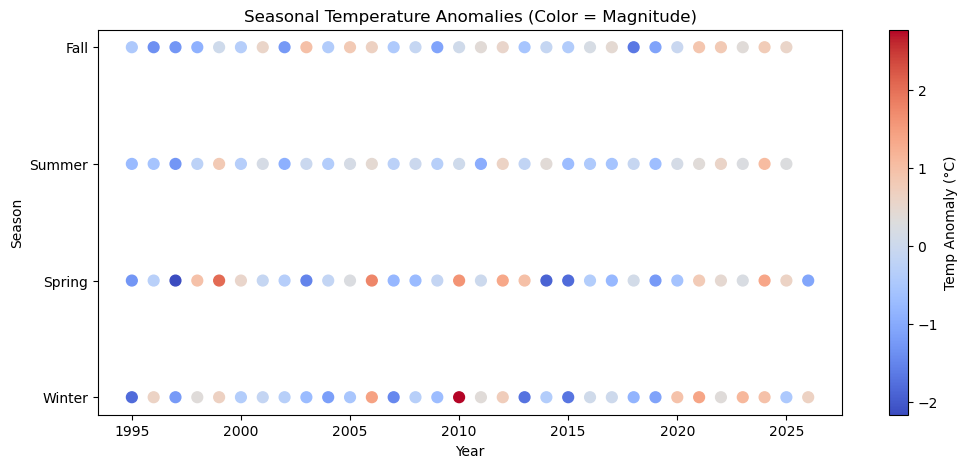

In [67]:
plt.figure(figsize=(12, 5))

season_map_order = {"Winter": 0, "Spring": 1, "Summer": 2, "Fall": 3}
seasonal_avg["Season_num"] = seasonal_avg["Season"].map(season_map_order)

plt.scatter(
    seasonal_avg["Year"],
    seasonal_avg["Season_num"],
    c=seasonal_avg["Temp Anomaly (°C)"],
    cmap="coolwarm",
    s=60
)

plt.yticks(
    list(season_map_order.values()),
    list(season_map_order.keys())
)

plt.colorbar(label="Temp Anomaly (°C)")
plt.xlabel("Year")
plt.ylabel("Season")
plt.title("Seasonal Temperature Anomalies (Color = Magnitude)")
plt.show()

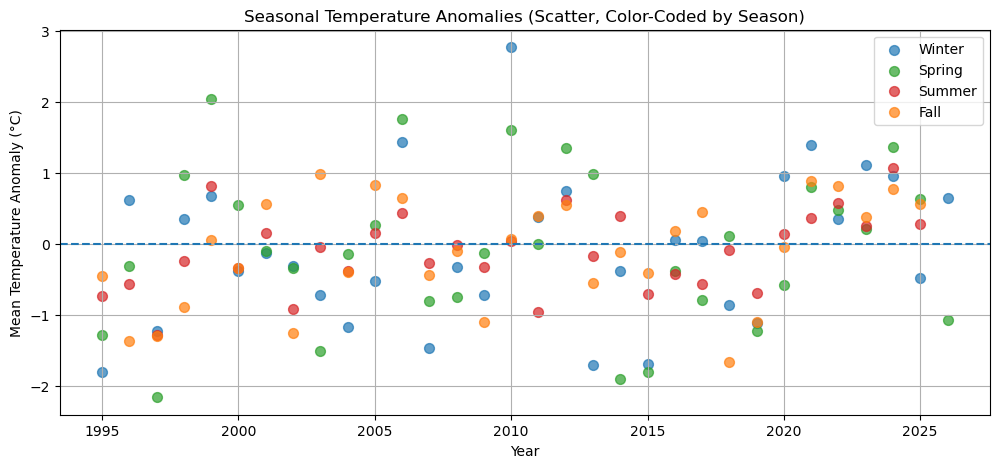

In [68]:
import matplotlib.pyplot as plt

# Aggregate across stations (optional but recommended for clarity)
seasonal_avg = (
    seasonal_anomaly
    .groupby(["Year", "Season"])["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

# Color map for seasons
season_colors = {
    "Winter": "tab:blue",
    "Spring": "tab:green",
    "Summer": "tab:red",
    "Fall": "tab:orange"
}

plt.figure(figsize=(12, 5))

for season, color in season_colors.items():
    data = seasonal_avg[seasonal_avg["Season"] == season]
    plt.scatter(
        data["Year"],
        data["Temp Anomaly (°C)"],
        color=color,
        label=season,
        s=50,
        alpha=0.7
    )

plt.axhline(0, linestyle="--")
plt.xlabel("Year")
plt.ylabel("Mean Temperature Anomaly (°C)")
plt.title("Seasonal Temperature Anomalies (Scatter, Color-Coded by Season)")
plt.legend()
plt.grid(True)
plt.show()

# Long‑term warming trends using temperature anomalies
- Goal
Quantify and visualize warming trends over time:

per station
per province
nationally (optional)

All trends are based on anomalies, not raw temperature (best practice).

In [69]:
required_cols = [
    "station_id", "Date", "Year",
    "Temp Anomaly (°C)", "Province"
]

missing = [c for c in required_cols if c not in df.columns]
missing

[]

## Create annual mean anomalies (station level)

In [70]:
annual_station_anomaly = (
    df.groupby(["station_id", "Year"], as_index=False)
      ["Temp Anomaly (°C)"]
      .mean()
)

## Compute long‑term trend per station

In [74]:
import numpy as np

def trend_per_decade(x, y):
    slope, _ = np.polyfit(x, y, 1)
    return slope * 10  # °C / decade

station_trends = (
    annual_station_anomaly
    .groupby("station_id")
    .apply(lambda g: trend_per_decade(g["Year"], g["Temp Anomaly (°C)"]))
    .reset_index(name="Trend (°C / decade)")
)
station_trends.head()

,station_id,Trend (°C / decade)
0,8100300,0.446855
1,8100467,0.040501
2,8100468,-10.809354
3,8100506,2.990688
4,8100885,0.294444


## Attach spatial metadata (for mapping & grouping)

In [117]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 833189 entries, 0 to 833188
Data columns (total 19 columns):
 #   Column                   Non-Null Count   Dtype         
---  ------                   --------------   -----         
 0   temp_Index               833189 non-null  int64         
 1   station_id               833189 non-null  object        
 2   Date/Time                833189 non-null  datetime64[us]
 3   Max Temp (°C)            828481 non-null  float64       
 4   Min Temp (°C)            831117 non-null  float64       
 5   Mean Temp (°C)           833189 non-null  float64       
 6   Heat Deg Days (°C)       826411 non-null  float64       
 7   Cool Deg Days (°C)       826411 non-null  float64       
 8   Year                     833189 non-null  int32         
 9   Month                    833189 non-null  int32         
 10  Day                      833189 non-null  int32         
 11  Latitude                 833189 non-null  float64       
 12  Longitude                83

In [118]:
station_trends = station_trends.merge(
    df[["station_id", "Latitude", "Longitude", "Province", "CSDNAME"]]
      .drop_duplicates(),
    on="station_id",
    how="left"
)

## Province‑level warming trends

In [119]:
annual_province_anomaly = (
    df.groupby(["Province", "Year"], as_index=False)
      ["Temp Anomaly (°C)"]
      .mean()
)

province_trends = (
    annual_province_anomaly
    .groupby("Province")
    .apply(lambda g: trend_per_decade(g["Year"], g["Temp Anomaly (°C)"]))
    .reset_index(name="Trend (°C / decade)")
    .sort_values("Trend (°C / decade)", ascending=False)
)

bi_anomaly_table = bi_anomaly_table.merge(
    df[["station_id", "Province"]].drop_duplicates(),
    on="station_id",
    how="left"
)


In [120]:
bi_anomaly_table.head()

,station_id,Date/Time,Baseline Mean Temp (°C),Temp Anomaly (°C),Province
0,8204020,2021-09-11,16.54,-2.84,Nova Scotia
1,8204020,2021-09-12,15.80,0.30,Nova Scotia
2,8204020,2021-09-13,17.14,-1.24,Nova Scotia
3,8204020,2021-09-14,15.64,-3.54,Nova Scotia
4,8204020,2021-09-15,14.30,-1.30,Nova Scotia


In [121]:
bi_anomaly_table = bi_anomaly_table.drop(
    columns=[c for c in bi_anomaly_table.columns if "Trend" in c],
    errors="ignore"
)
bi_anomaly_table = bi_anomaly_table.merge(
    province_trends,
    on="Province",
    how="left"
)

bi_anomaly_table.rename(
    columns={"Trend (°C / decade)": "Province Trend (°C / decade)"},
    inplace=True
)


In [122]:
bi_anomaly_table.head()

,station_id,Date/Time,Baseline Mean Temp (°C),Temp Anomaly (°C),Province,Province Trend (°C / decade)
0,8204020,2021-09-11,16.54,-2.84,Nova Scotia,0.200511
1,8204020,2021-09-12,15.80,0.30,Nova Scotia,0.200511
2,8204020,2021-09-13,17.14,-1.24,Nova Scotia,0.200511
3,8204020,2021-09-14,15.64,-3.54,Nova Scotia,0.200511
4,8204020,2021-09-15,14.30,-1.30,Nova Scotia,0.200511


## check

In [123]:
station_trends["Trend (°C / decade)"].describe()
province_trends

,Province,Trend (°C / decade)
3,Prince Edward Island,0.320756
1,Newfoundland and Labrador,0.220537
2,Nova Scotia,0.200511
0,New Brunswick,0.149002


# Heatwave Detection Using Temperature Anomalies
- Definition (clear & climate‑standard)
We will define a heatwave as:

≥ 3 consecutive days where
Daily temperature anomaly ≥ +2.0 °C
relative to the 30‑year station baseline

✅ Station‑specific
✅ Baseline‑relative
✅ Robust across regions
(Thresholds can be adjusted later.)

In [79]:
df = df.sort_values(["station_id", "Date"]).reset_index(drop=True)
df.head(3)

,temp_Index,station_id,Date,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Year,Month,Day,Latitude,Longitude,CSDUID,CSDNAME,Province,Baseline Mean Temp (°C),Temp Anomaly (°C),Season
0,11985,8100300,1995-01-01,-8.0,-14.0,-11.0,29.0,0.0,1995,1,1,46.71,-67.72,1312004,Perth,New Brunswick,-8.660000,-2.340000,Winter
1,11986,8100300,1995-01-02,-4.0,-9.0,-6.5,24.5,0.0,1995,1,2,46.71,-67.72,1312004,Perth,New Brunswick,-9.565385,3.065385,Winter
2,11987,8100300,1995-01-03,-6.0,-10.5,-8.3,26.3,0.0,1995,1,3,46.71,-67.72,1312004,Perth,New Brunswick,-10.623077,2.323077,Winter


## Flag heatwave‑candidate days

In [80]:
HEATWAVE_THRESHOLD = 2.0  # °C anomaly

df["hw_day"] = df["Temp Anomaly (°C)"] >= HEATWAVE_THRESHOLD

## Identify consecutive heatwave runs per station

In [81]:
# Start a new group when hw_day changes OR station changes
df["hw_group"] = (
    df["hw_day"]
    .ne(df["hw_day"].shift())
    | df["station_id"].ne(df["station_id"].shift())
).cumsum()

## Extract valid heatwave events (≥ 3 days)

In [83]:
heatwaves = (
    df[df["hw_day"]]
    .groupby(["station_id", "hw_group"])
    .agg(
        start_date=("Date", "min"),
        end_date=("Date", "max"),
        duration_days=("Date", "count"),
        mean_anomaly=("Temp Anomaly (°C)", "mean"),
        max_anomaly=("Temp Anomaly (°C)", "max")
    )
    .reset_index()  # ✅ DO NOT drop index
)
heatwaves = heatwaves[heatwaves["duration_days"] >= 3]

In [84]:
heatwaves = heatwaves.drop(
    columns=[c for c in heatwaves.columns 
             if c in ["Latitude", "Longitude", "Province", "CSDNAME"]],
    errors="ignore"
)

In [85]:

heatwaves = heatwaves.merge(
    df[["station_id", "Latitude", "Longitude", "Province", "CSDNAME"]]
      .drop_duplicates(),
    on="station_id",
    how="left"
)
heatwaves.head()

,station_id,hw_group,start_date,end_date,duration_days,mean_anomaly,max_anomaly,Latitude,Longitude,Province,CSDNAME
0,8100300,4,1995-01-13,1995-01-25,13,9.660637,18.404000,46.71,-67.72,New Brunswick,Perth
1,8100300,14,1995-03-13,1995-03-19,7,4.779635,6.195833,46.71,-67.72,New Brunswick,Perth
2,8100300,16,1995-03-21,1995-03-23,3,5.663889,6.395833,46.71,-67.72,New Brunswick,Perth
3,8100300,18,1995-05-12,1995-05-14,3,4.146667,4.616000,46.71,-67.72,New Brunswick,Perth
4,8100300,20,1995-05-31,1995-06-03,4,4.324038,6.500000,46.71,-67.72,New Brunswick,Perth


In [100]:
import pandas as pd

heatwaves["start_date"] = pd.to_datetime(heatwaves["start_date"])
heatwaves["end_date"] = pd.to_datetime(heatwaves["end_date"])
heatwaves_2010_2025 = heatwaves[
    (heatwaves["start_date"] >= "2010-01-01") &
    (heatwaves["start_date"] <= "2025-12-31")
]
heatwaves_2010_2025_final = heatwaves_2010_2025[
    [
        "station_id",
        "hw_group",
        "start_date",
        "end_date",
        "duration_days",
        "mean_anomaly",
        "max_anomaly",
    ]
]

In [101]:
heatwaves_2010_2025_final.head()

,station_id,hw_group,start_date,end_date,duration_days,mean_anomaly,max_anomaly
144,8100300,836,2010-01-02,2010-01-08,7,9.250128,12.668000
145,8100300,840,2010-01-19,2010-01-22,4,7.170149,11.344000
146,8100300,842,2010-01-25,2010-01-29,5,8.671077,14.234615
147,8100300,844,2010-02-07,2010-03-09,31,7.950397,13.004000
148,8100300,846,2010-03-13,2010-03-20,8,6.060306,9.587500


In [102]:
heatwaves_2010_2025_final["start_date"].min(), \
heatwaves_2010_2025_final["start_date"].max()

(Timestamp('2010-01-01 00:00:00'), Timestamp('2025-12-30 00:00:00'))

In [103]:
heatwaves_2010_2025_final.to_csv(
    "heatwaves_2010_2025.csv",
    index=False
)

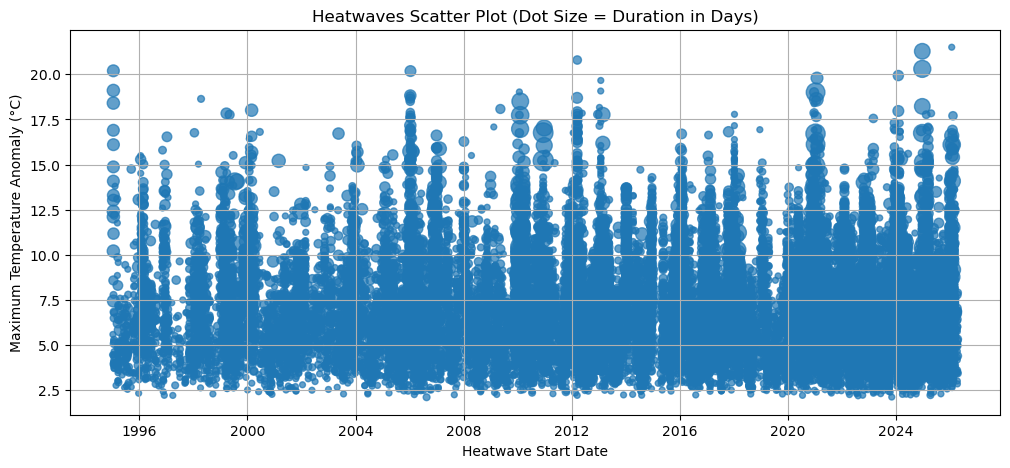

In [86]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure dates are datetime
heatwaves["start_date"] = pd.to_datetime(heatwaves["start_date"])

plt.figure(figsize=(12, 5))

plt.scatter(
    heatwaves["start_date"],
    heatwaves["max_anomaly"],
    s=heatwaves["duration_days"] * 6,   # size reflects duration
    alpha=0.7
)

plt.xlabel("Heatwave Start Date")
plt.ylabel("Maximum Temperature Anomaly (°C)")
plt.title("Heatwaves Scatter Plot (Dot Size = Duration in Days)")
plt.grid(True)
plt.show()

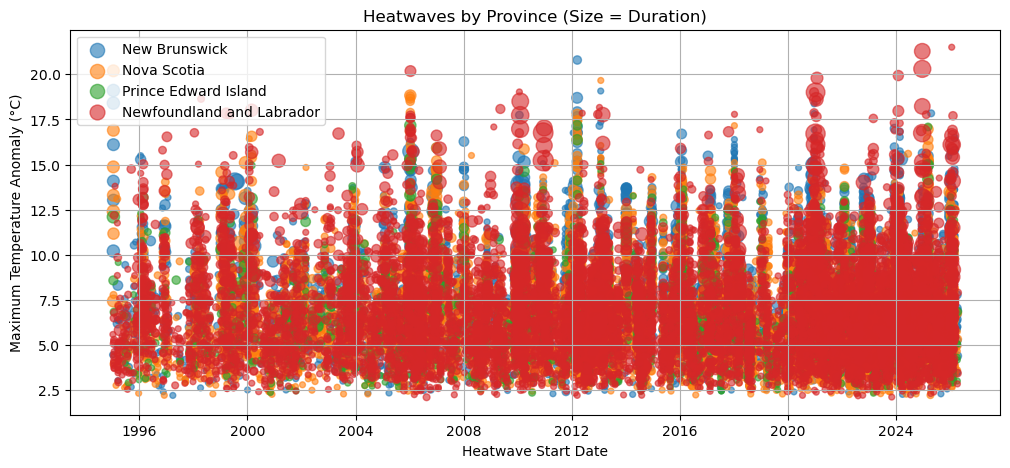

In [87]:
plt.figure(figsize=(12, 5))

for province in heatwaves["Province"].unique():
    p_df = heatwaves[heatwaves["Province"] == province]
    plt.scatter(
        p_df["start_date"],
        p_df["max_anomaly"],
        s=p_df["duration_days"] * 6,
        alpha=0.6,
        label=province
    )

plt.xlabel("Heatwave Start Date")
plt.ylabel("Maximum Temperature Anomaly (°C)")
plt.title("Heatwaves by Province (Size = Duration)")
plt.legend()
plt.grid(True)
plt.show()


## Heatwave frequency analysis

In [90]:
heatwaves["Year"] = heatwaves["start_date"].dt.year

station_hw_freq = (
    heatwaves.groupby(["station_id", "Year"])
    .size()
    .reset_index(name="heatwave_count")
)

In [92]:
province_hw_freq = (
    heatwaves.groupby(["Province", "Year"])
    .size()
    .reset_index(name="heatwave_count")
)
province_hw_freq.info()

<class 'pandas.DataFrame'>
RangeIndex: 128 entries, 0 to 127
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Province        128 non-null    str  
 1   Year            128 non-null    int32
 2   heatwave_count  128 non-null    int64
dtypes: int32(1), int64(1), str(1)
memory usage: 2.6 KB


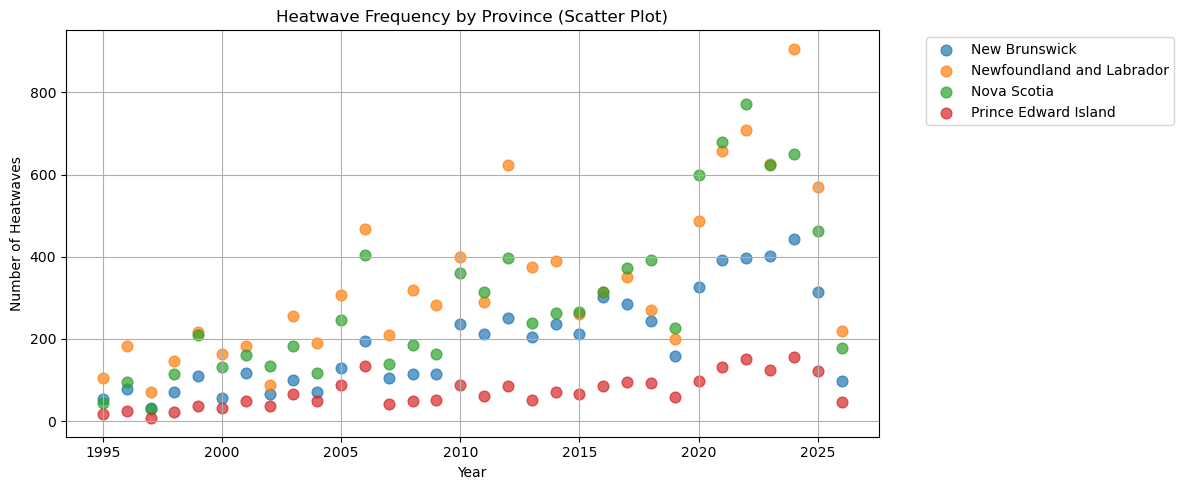

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

for province in province_hw_freq["Province"].unique():
    data = province_hw_freq[province_hw_freq["Province"] == province]
    
    plt.scatter(
        data["Year"],
        data["heatwave_count"],
        s=60,
        alpha=0.7,
        label=province
    )

plt.xlabel("Year")
plt.ylabel("Number of Heatwaves")
plt.title("Heatwave Frequency by Province (Scatter Plot)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [94]:
stations_per_province = (
    heatwaves[["Province", "station_id"]]
    .drop_duplicates()
    .groupby("Province")
    .size()
    .reset_index(name="num_stations")
)

stations_per_province

,Province,num_stations
0,New Brunswick,27
1,Newfoundland and Labrador,51
2,Nova Scotia,50
3,Prince Edward Island,8


In [97]:
events_per_station = (
    heatwaves
    .groupby(["Province", "station_id", "CSDNAME"])
    .size()
    .reset_index(name="heatwave_events")
)
events_per_station.head()

,Province,station_id,CSDNAME,heatwave_events
0,New Brunswick,8100300,Perth,378
1,New Brunswick,8100467,Bas-Caraquet,391
2,New Brunswick,8100468,Bas-Caraquet,1
3,New Brunswick,8100506,Bathurst,96
4,New Brunswick,8100885,Charlo,284


## Heatwave intensity metrics

In [46]:
heatwaves[[
    "duration_days",
    "mean_anomaly",
    "max_anomaly"
]].describe()

,duration_days,mean_anomaly,max_anomaly
count,28965.000000,28965.000000,28965.000000
mean,4.714587,4.784339,6.864233
std,2.552700,1.512289,2.643242
min,3.000000,2.104915,2.173333
25%,3.000000,3.671241,4.920000
50%,4.000000,4.520772,6.400000
75%,5.000000,5.623810,8.340000
max,35.000000,14.043821,23.209091


# Spatial gradients
- Where heatwaves are intensifying fastest
- A) Warming rate vs latitude
- Use the station‑level warming rates (°C/decade) you already computed earlier.

In [47]:
# station_trends already exists with:
# ['station_id', 'Trend (°C / decade)', 'Latitude', 'Longitude', 'Province', 'CSDNAME']

station_trends[["Latitude", "Trend (°C / decade)"]].describe()

,Latitude,Trend (°C / decade)
count,136.000000,136.000000
mean,47.379265,0.265172
std,3.051183,2.134581
min,43.450000,-18.667147
25%,45.275000,0.193339
50%,46.505000,0.371646
75%,48.560000,0.760501
max,58.480000,4.522492


In [48]:
station_trends[["Latitude", "Trend (°C / decade)"]].corr()

,Latitude,Trend (°C / decade)
Latitude,1.000000,-0.047154
Trend (°C / decade),-0.047154,1.000000


## Bin by latitude bands (clear climate signal)
- Interpretation: higher latitudes warming faster is a classic fingerprint; deviations tell regional stories.

In [49]:
station_trends["lat_band"] = pd.cut(
    station_trends["Latitude"],
    bins=[40, 45, 50, 55, 60],
    labels=["40–45", "45–50", "50–55", "55–60"]
)

lat_band_trends = (
    station_trends
    .groupby("lat_band")["Trend (°C / decade)"]
    .mean()
    .reset_index()
)
lat_band_trends

,lat_band,Trend (°C / decade)
0,40–45,0.250785
1,45–50,0.348279
2,50–55,-0.719409
3,55–60,1.265310


## Heatwave intensity vs latitude

In [52]:
hw_lat = (
    heatwaves
    .groupby("station_id", as_index=False)
    .agg(
        mean_hw_duration=("duration_days", "mean"),
        max_hw_anomaly=("max_anomaly", "max")
    )
    .merge(
        station_trends[["station_id", "Latitude"]],
        on="station_id",
        how="left"
    )
)
hw_lat_numeric = hw_lat[
    ["Latitude", "mean_hw_duration", "max_hw_anomaly"]
]

hw_lat_numeric.corr()

,Latitude,mean_hw_duration,max_hw_anomaly
Latitude,1.000000,0.681320,0.327757
mean_hw_duration,0.681320,1.000000,0.392687
max_hw_anomaly,0.327757,0.392687,1.000000


In [51]:
hw_lat.dtypes

station_id           object
mean_hw_duration    float64
max_hw_anomaly      float64
Latitude            float64
dtype: object

# Trend in heatwaves
- Are heatwaves becoming more frequent/longer?

- Interpretation:

↑ frequency → more frequent blocking patterns
↑ duration → more persistent extremes (higher risk)

## Event frequency per year

In [54]:
annual_hw_count = (
    heatwaves
    .groupby("Year")
    .size()
    .reset_index(name="heatwave_events")
)

annual_hw_count.head()

,Year,heatwave_events
0,1995,225
1,1996,383
2,1997,134
3,1998,349
4,1999,573


In [57]:
heatwaves.groupby("Year")["station_id"].nunique().head()

Year
1995    33
1996    34
1997    33
1998    33
1999    35
Name: station_id, dtype: int64

## Trend (events per decade)

In [55]:
import numpy as np

slope_events_per_decade = (
    np.polyfit(
        annual_hw_count["Year"],
        annual_hw_count["heatwave_events"],
        1
    )[0] * 10
)

slope_events_per_decade

np.float64(447.74743401759844)

## Duration trend

In [56]:
annual_hw_duration = (
    heatwaves
    .groupby("Year")["duration_days"]
    .mean()
    .reset_index(name="mean_duration")
)

duration_trend_per_decade = (
    np.polyfit(
        annual_hw_duration["Year"],
        annual_hw_duration["mean_duration"],
        1
    )[0] * 10
)

duration_trend_per_decade

np.float64(0.008930308189324127)

# Viz

## Long‑term temperature anomaly trend (Atlantic mean)
- Purpose: Shows climate change signal clearly (noise removed)

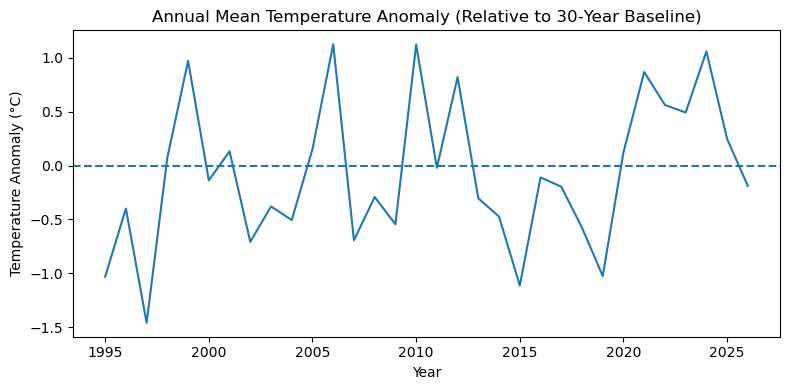

In [59]:
import matplotlib.pyplot as plt

annual_anomaly = (
    df.groupby("Year")["Temp Anomaly (°C)"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(annual_anomaly["Year"], annual_anomaly["Temp Anomaly (°C)"])
plt.axhline(0, linestyle="--")
plt.title("Annual Mean Temperature Anomaly (Relative to 30‑Year Baseline)")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.tight_layout()
plt.show()

## Monthly anomaly climatology
- Purpose: Seasonality of warming
- ✅ Shows winter amplification vs summer extremes.

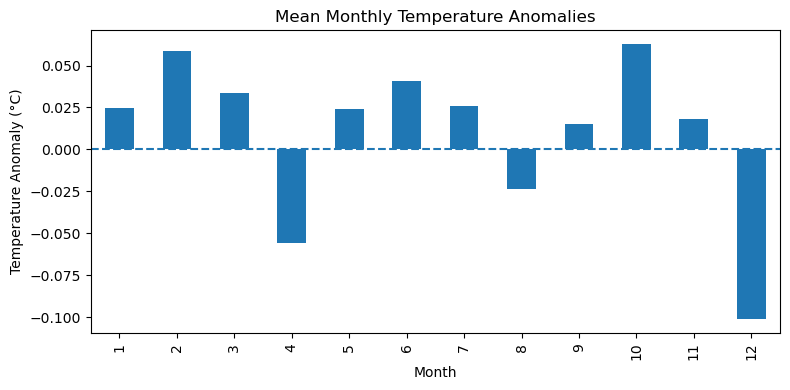

In [60]:
monthly_anomaly = (
    df.groupby("Month")["Temp Anomaly (°C)"]
      .mean()
)

plt.figure(figsize=(8,4))
monthly_anomaly.plot(kind="bar")
plt.axhline(0, linestyle="--")
plt.title("Mean Monthly Temperature Anomalies")
plt.xlabel("Month")
plt.ylabel("Temperature Anomaly (°C)")
plt.tight_layout()
plt.show()

## Total heatwave events per year (all stations)
- Purpose: National exposure / climate burden
⚠️ Reminder: this is not per station — it is total exposure.

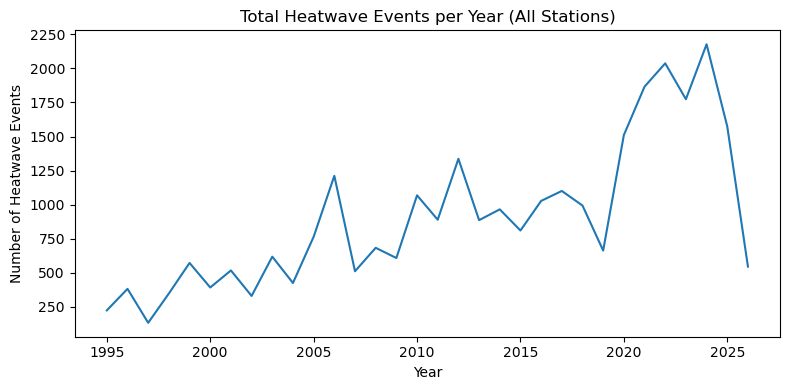

In [62]:
annual_hw_events = (
    heatwaves.groupby("Year")
    .size()
    .reset_index(name="Total Heatwave Events")
)

plt.figure(figsize=(8,4))
plt.plot(annual_hw_events["Year"], annual_hw_events["Total Heatwave Events"])
plt.title("Total Heatwave Events per Year (All Stations)")
plt.xlabel("Year")
plt.ylabel("Number of Heatwave Events")
plt.tight_layout()
plt.show()

## Average heatwaves per station per year (best practice trend)
- Purpose: Proper climate signal 

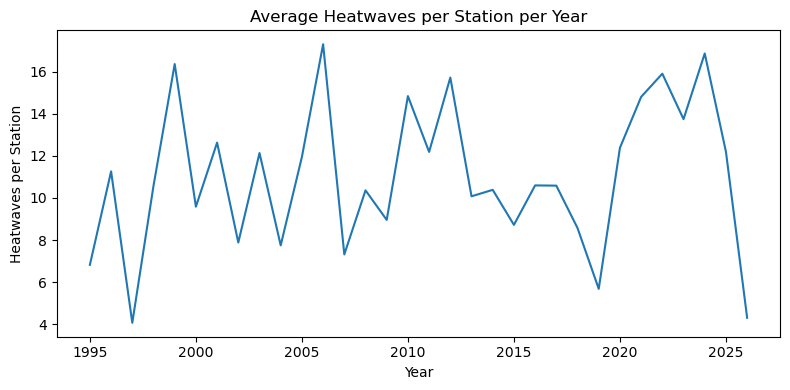

In [63]:
avg_hw_per_station = (
    heatwaves
    .groupby(["station_id", "Year"])
    .size()
    .groupby("Year")
    .mean()
    .reset_index(name="Avg Heatwaves per Station")
)

plt.figure(figsize=(8,4))
plt.plot(avg_hw_per_station["Year"], avg_hw_per_station["Avg Heatwaves per Station"])
plt.title("Average Heatwaves per Station per Year")
plt.xlabel("Year")
plt.ylabel("Heatwaves per Station")
plt.tight_layout()
plt.show()

## Heatwave duration trend
- ✅ Rising duration = more dangerous extremes.

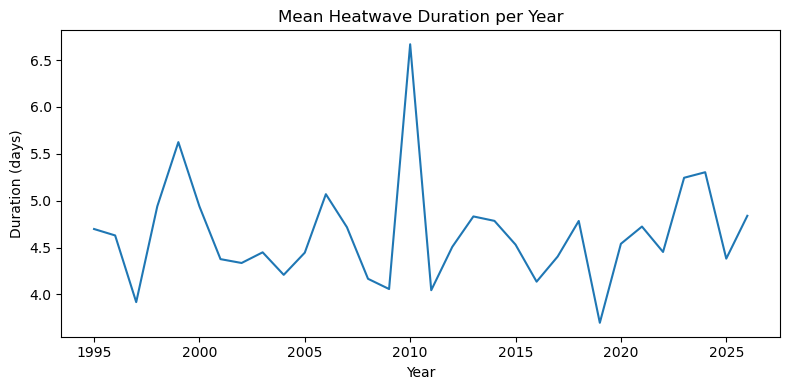

In [64]:
mean_hw_duration = (
    heatwaves.groupby("Year")["duration_days"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,4))
plt.plot(mean_hw_duration["Year"], mean_hw_duration["duration_days"])
plt.title("Mean Heatwave Duration per Year")
plt.xlabel("Year")
plt.ylabel("Duration (days)")
plt.tight_layout()
plt.show()

## Heatwave intensity vs latitude (spatial gradient)

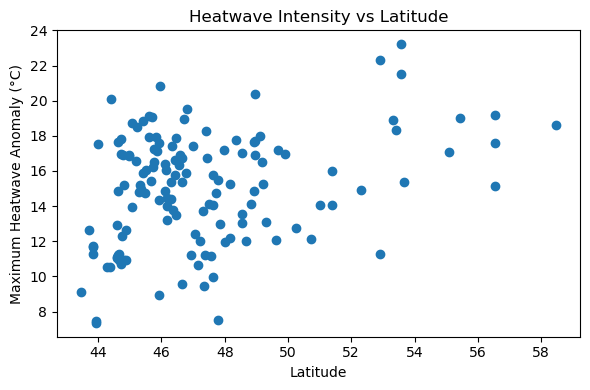

In [65]:
hw_lat = (
    heatwaves
    .groupby("station_id", as_index=False)
    .agg(
        mean_duration=("duration_days", "mean"),
        max_intensity=("max_anomaly", "max"),
        Latitude=("Latitude", "first")
    )
)

plt.figure(figsize=(6,4))
plt.scatter(hw_lat["Latitude"], hw_lat["max_intensity"])
plt.xlabel("Latitude")
plt.ylabel("Maximum Heatwave Anomaly (°C)")
plt.title("Heatwave Intensity vs Latitude")
plt.tight_layout()
plt.show()

# City‑level temperature anomalies
- CSDNAME → city / census subdivision

In [66]:
city_daily_anomaly = (
    df.groupby(["CSDNAME", "Date/Time"], as_index=False)
      ["Temp Anomaly (°C)"]
      .mean()
)

In [67]:
city_annual_anomaly = (
    df.groupby(["CSDNAME", "Year"], as_index=False)
      ["Temp Anomaly (°C)"]
      .mean()
)


## Example: compare major cities

In [68]:
cities = ["Saint John", "Cape Breton", "Halifax"]

city_annual_anomaly[
    city_annual_anomaly["CSDNAME"].isin(cities)
].head()

,CSDNAME,Year,Temp Anomaly (°C)
240,Cape Breton,2006,0.888319
241,Cape Breton,2007,-0.790235
242,Cape Breton,2008,-0.326481
243,Cape Breton,2009,-0.658728
244,Cape Breton,2010,0.711683


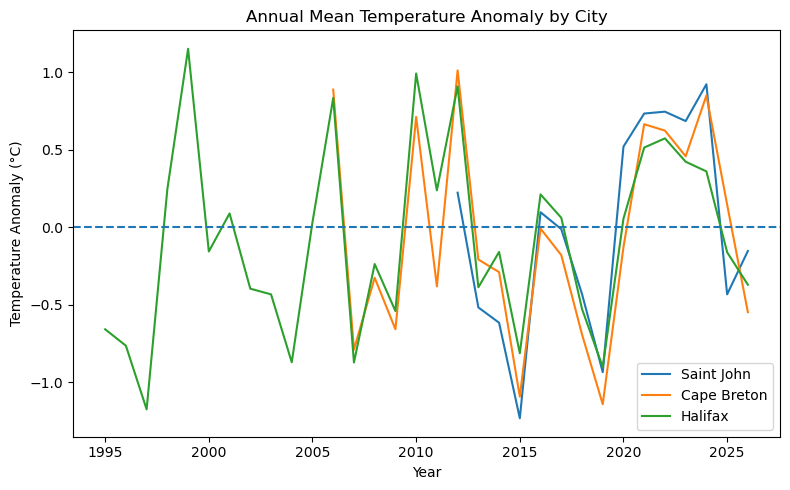

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

for city in cities:
    subset = city_annual_anomaly[
        city_annual_anomaly["CSDNAME"] == city
    ]
    plt.plot(subset["Year"], subset["Temp Anomaly (°C)"], label=city)

plt.axhline(0, linestyle="--")
plt.legend()
plt.title("Annual Mean Temperature Anomaly by City")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.tight_layout()
plt.show()

#  Province‑level temperature anomalies

In [70]:
province_annual_anomaly = (
    df.groupby(["Province", "Year"], as_index=False)
      ["Temp Anomaly (°C)"]
      .mean()
)

## Rank provinces by warming trend

In [71]:
import numpy as np

province_trends = (
    province_annual_anomaly
    .groupby("Province")
    .apply(
        lambda g: np.polyfit(
            g["Year"], g["Temp Anomaly (°C)"], 1
        )[0] * 10   # °C per decade
    )
    .reset_index(name="Warming Rate (°C / decade)")
    .sort_values("Warming Rate (°C / decade)", ascending=False)
)

province_trends

,Province,Warming Rate (°C / decade)
3,Prince Edward Island,0.322168
1,Newfoundland and Labrador,0.227203
2,Nova Scotia,0.192123
0,New Brunswick,0.142161


## Visualize province anomalies

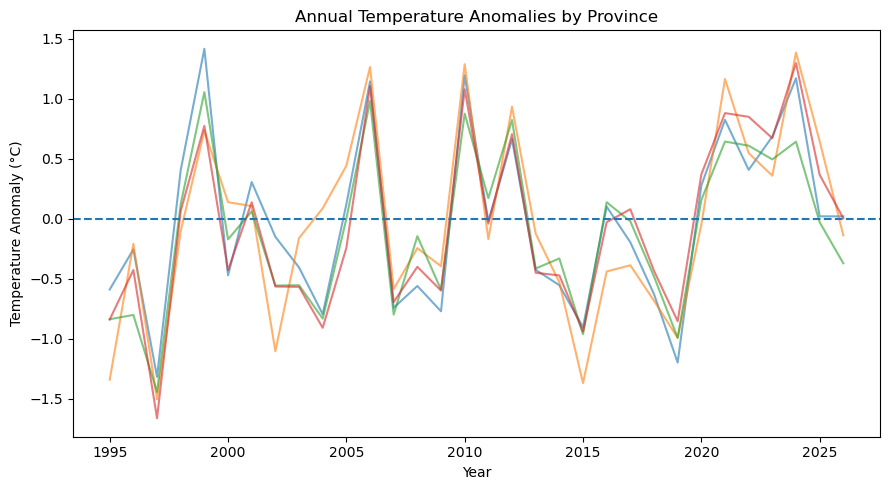

In [72]:
plt.figure(figsize=(9,5))

for prov in province_annual_anomaly["Province"].unique():
    subset = province_annual_anomaly[
        province_annual_anomaly["Province"] == prov
    ]
    plt.plot(subset["Year"], subset["Temp Anomaly (°C)"], alpha=0.6)

plt.axhline(0, linestyle="--")
plt.title("Annual Temperature Anomalies by Province")
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.tight_layout()
plt.show()

# Heatwaves by city and province

In [75]:
city_hw_freq = (
    heatwaves.groupby(["CSDNAME", "Year"])
    .size()
    .reset_index(name="Heatwave Events")
)
city_hw_freq

,CSDNAME,Year,Heatwave Events
0,Allardville,2010,8
1,Allardville,2011,9
2,Allardville,2012,15
3,Allardville,2013,9
4,Allardville,2014,14
...,...,...,...
2038,Yarmouth,2022,43
2039,Yarmouth,2023,42
2040,Yarmouth,2024,31
2041,Yarmouth,2025,24


In [76]:
province_hw_freq = (
    heatwaves.groupby(["Province", "Year"])
    .size()
    .reset_index(name="Heatwave Events")
)
province_hw_freq

,Province,Year,Heatwave Events
0,New Brunswick,1995,55
1,New Brunswick,1996,76
2,New Brunswick,1997,30
3,New Brunswick,1998,70
4,New Brunswick,1999,111
...,...,...,...
123,Prince Edward Island,2022,152
124,Prince Edward Island,2023,130
125,Prince Edward Island,2024,161
126,Prince Edward Island,2025,125


# Temperature trend estimation: Linear & Polynomial fits
- Linear & Polynomial Fits Using Anomalies
- Scope (explicit and correct)

Region: Atlantic Canada
Provinces: NS, NB, NL, PEI
Variable: Temperature anomalies (°C)
Baseline: Your 30‑year station‑level baseline
Temporal resolution: Annual means (required for trends)

##  Define Atlantic Canada subset

In [84]:
atlantic_provinces = [
    "Nova Scotia",
    "New Brunswick",
    "Newfoundland and Labrador",
    "Prince Edward Island"
]

df_atlantic = df[df["Province"].isin(atlantic_provinces)].copy()

df_atlantic = df[df["Province"].isin(atlantic_provinces)].copy()

## Step 2 — Compute Atlantic‑wide annual mean anomaly

In [85]:
atlantic_annual_anomaly = (
    df_atlantic
    .groupby("Year")["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

# PART A — Linear trend (primary result)
- ✅ Step 3 — Linear regression (°C per decade)
- ✅ Interpretation

Atlantic Canada has warmed at a rate of X °C per decade,
relative to the chosen 30‑year baseline.

This is the number you report in text, tables, and abstracts.

In [86]:
import numpy as np

slope, intercept = np.polyfit(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    1
)

atlantic_trend_c_per_decade = slope * 10
atlantic_trend_c_per_decade

np.float64(0.2050939273988368)

## ✅ Step 4 — Plot linear trend

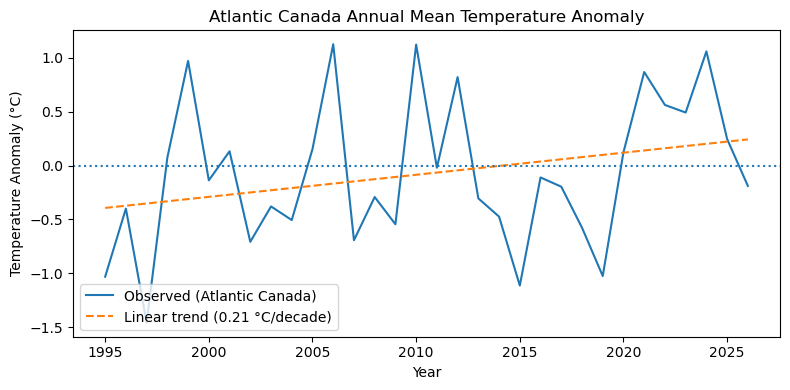

In [87]:
import numpy as np
import matplotlib.pyplot as plt

# Recompute linear regression (safe even if already done)
slope, intercept = np.polyfit(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    1
)

trend_per_decade = slope * 10

# Plot
plt.figure(figsize=(8,4))

plt.plot(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    label="Observed (Atlantic Canada)"
)

plt.plot(
    atlantic_annual_anomaly["Year"],
    slope * atlantic_annual_anomaly["Year"] + intercept,
    linestyle="--",
    label=f"Linear trend ({trend_per_decade:.2f} °C/decade)"
)

plt.axhline(0, linestyle=":")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada Annual Mean Temperature Anomaly")
plt.tight_layout()
plt.show()

In [88]:
len(df)

833189

In [83]:
df["Province"].value_counts()

Province
Newfoundland and Labrador    315381
Nova Scotia                  287110
New Brunswick                168893
Prince Edward Island          61805
Name: count, dtype: int64

# 🟧 PART B — Polynomial fit (secondary / diagnostic)
-Polynomial fits are not a replacement for linear trends.
They are used to explore non‑linearity or acceleration.

## Step 5 — Quadratic (2nd‑order) fit

In [89]:
coeffs_2 = np.polyfit(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    2
)

poly2 = np.poly1d(coeffs_2)

## Step 6 — Compare linear vs polynomial fits

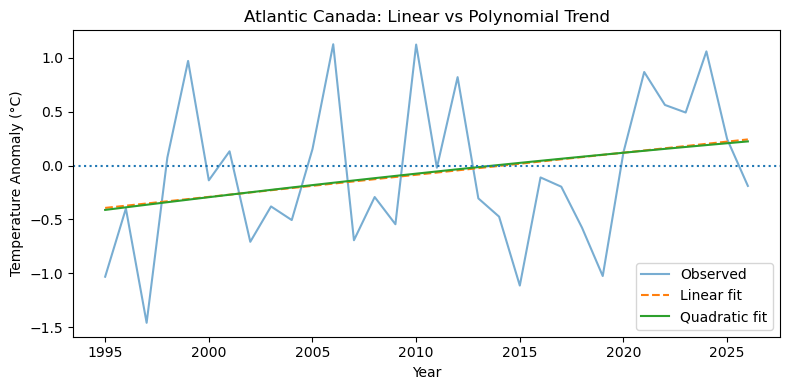

In [92]:
plt.figure(figsize=(8,4))

plt.plot(
    atlantic_annual_anomaly["Year"],
    atlantic_annual_anomaly["Temp Anomaly (°C)"],
    label="Observed",
    alpha=0.6
)

plt.plot(
    atlantic_annual_anomaly["Year"],
    slope * atlantic_annual_anomaly["Year"] + intercept,
    linestyle="--",
    label="Linear fit"
)

plt.plot(
    atlantic_annual_anomaly["Year"],
    poly2(atlantic_annual_anomaly["Year"]),
    label="Quadratic fit"
)

plt.axhline(0, linestyle=":")
plt.legend()
plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title("Atlantic Canada: Linear vs Polynomial Trend")
plt.tight_layout()
plt.show()

## 🟩 PART C — Province‑level linear trends (recommended)
This answers:

“Which Atlantic provinces are warming fastest?”

In [93]:
province_annual_anomaly = (
    df_atlantic
    .groupby(["Province", "Year"])["Temp Anomaly (°C)"]
    .mean()
    .reset_index()
)

province_trends = (
    province_annual_anomaly
    .groupby("Province")
    .apply(
        lambda g: np.polyfit(
            g["Year"],
            g["Temp Anomaly (°C)"],
            1
        )[0] * 10
    )
    .reset_index(name="Trend (°C / decade)")
    .sort_values("Trend (°C / decade)", ascending=False)
)

province_trends

,Province,Trend (°C / decade)
3,Prince Edward Island,0.322168
1,Newfoundland and Labrador,0.227203
2,Nova Scotia,0.192123
0,New Brunswick,0.142161


Bottom‑line interpretation of the plot

Atlantic Canada has experienced sustained regional warming since the mid‑1990s, with recent decades dominated by positive temperature anomalies. A linear trend adequately captures the long‑term warming signal, while year‑to‑year variability reflects natural climate fluctuations.

## Provincial insights


### 🔥 Prince Edward Island (fastest warming)

~0.32 °C per decade
Roughly 1 °C of warming over ~30 years
Small land area + maritime influence → strong sensitivity

✅ This is a notable and policy‑relevant signal.


### 🌊 Newfoundland and Labrador

~0.23 °C per decade
Strong regional warming despite North Atlantic variability
Likely influenced by:

ocean circulation changes,
reduced cold extremes.





### 🌬️ Nova Scotia

~0.19 °C per decade
Consistent warming, moderated by strong marine influence

### 🌲 New Brunswick (slowest, but still warming)

~0.14 °C per decade
Still clearly positive — no province shows cooling

✅ Important point:
Lower does not mean negligible — this is still significant warming over multi‑decadal periods.